# NumPy Dojo — Block 1: Data Preprocessing

Dataset: **sklearn digits** (real 8×8 grayscale images, 1797 samples, 10 classes)  
Plus a synthetic **fake RGB image batch** for color/channel work.

Rules:
- No scipy, no sklearn transforms, no cv2 — only numpy (and matplotlib for viz)
- If you can't remember a function name, implement it from math
- Run asserts after every problem — green = correct

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [2]:

# Load digits dataset
digits = load_digits()
X_raw = digits.data          # (1797, 64) — flattened 8x8 images, float64, range [0, 16]
y = digits.target            # (1797,) — class labels 0-9
images = digits.images       # (1797, 8, 8) — 2D images

In [3]:

# Synthetic RGB image batch — mimics a real loader output
np.random.seed(42)
rgb_batch = np.random.randint(0, 256, size=(16, 32, 32, 3), dtype=np.uint8)  # (B, H, W, C)

In [4]:

print(f'X_raw shape: {X_raw.shape}, dtype: {X_raw.dtype}')
print(f'images shape: {images.shape}')
print(f'rgb_batch shape: {rgb_batch.shape}, dtype: {rgb_batch.dtype}')


X_raw shape: (1797, 64), dtype: float64
images shape: (1797, 8, 8)
rgb_batch shape: (16, 32, 32, 3), dtype: uint8


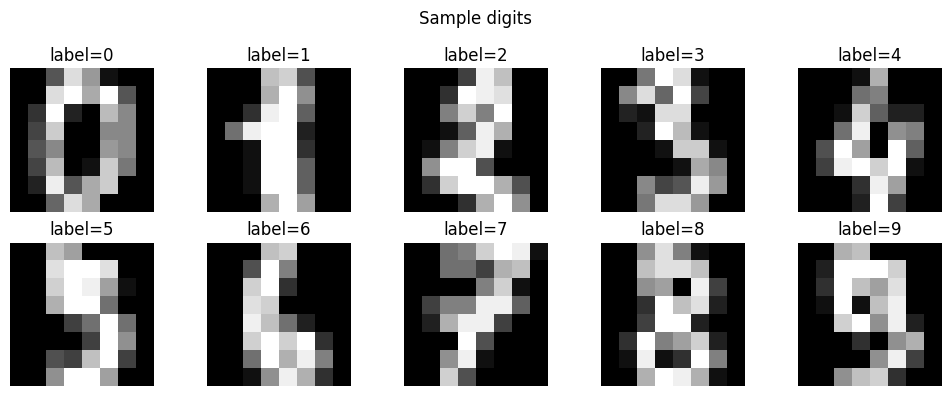

In [5]:

# Quick look at the data
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'label={y[i]}')
    ax.axis('off')
plt.suptitle('Sample digits')
plt.tight_layout()
plt.show()

---
## P1 — Z-score Standardization

Standardize `X_raw` **per feature** (column-wise) to mean=0, std=1.  
Edge case: if a feature has std=0, output 0 for that feature (don't divide by zero).

In [ ]:
def standardize(X):
    """
    X: (N, D)
    Returns: X_std (N, D), mean (D,), std (D,)
    """
    # TODO: compute per-feature mean and std
    # TODO: divide — but guard against std=0
    # Hint: think about what keepdims does for you here

    
    
    return X_std, mean_per_feat, std_per_feat

X_std, feat_mean, feat_std = standardize(X_raw)

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_64275/3950919214.py:14: RuntimeWarning: invalid value encountered in divide
  X_std = ((X - mean_per_feat )/std_per_feat)


In [12]:
X_raw.shape, X_std.shape, feat_mean.shape, feat_std.shape

((1797, 64), (1797, 64), (1, 64), (1, 64))

In [8]:
# --- ASSERTS ---
assert X_std.shape == X_raw.shape, 'Shape mismatch'

# Columns with non-zero std should have mean≈0, std≈1
active_cols = feat_std > 0
col_means = X_std[:, active_cols].mean(axis=0)
col_stds  = X_std[:, active_cols].std(axis=0)
assert np.allclose(col_means, 0, atol=1e-6), f'Mean not 0: max={col_means.max():.4f}'
assert np.allclose(col_stds,  1, atol=1e-6), f'Std not 1: max={col_stds.max():.4f}'

# Zero-std columns should output 0 (no NaN)
assert not np.any(np.isnan(X_std)), 'NaN found — zero-std guard failed'
print('P1 PASSED ✓')

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
# Visualize: before vs after for one feature
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(X_raw[:, 10], bins=30, color='steelblue')
axes[0].set_title('Feature 10 — raw')
axes[1].hist(X_std[:, 10], bins=30, color='tomato')
axes[1].set_title('Feature 10 — standardized')
plt.tight_layout()
plt.show()

---
## P2 — Min-Max Normalization to [a, b]

Scale `X_raw` per-feature to the range `[-1, 1]`.  
Edge case: if min == max for a feature, output 0 for that feature.

In [ ]:
def minmax_normalize(X, a=-1, b=1):
    """
    X: (N, D)
    Returns: X_norm (N, D) with each feature scaled to [a, b]
    """
    # TODO: compute per-feature min and max
    # TODO: scale — guard against range=0
    # The formula: X_norm = a + (X - X_min) / (X_max - X_min) * (b - a)
    pass

X_mm = minmax_normalize(X_raw)

In [ ]:
# --- ASSERTS ---
assert X_mm.shape == X_raw.shape

active_cols = (X_raw.max(axis=0) - X_raw.min(axis=0)) > 0
assert X_mm[:, active_cols].min() >= -1 - 1e-6
assert X_mm[:, active_cols].max() <=  1 + 1e-6
assert not np.any(np.isnan(X_mm))
print('P2 PASSED ✓')

---
## P3 — Image Batch Preprocessing Pipeline

Work with `rgb_batch` of shape **(B=16, H=32, W=32, C=3)**, dtype uint8, values [0, 255].

Steps (in order):
1. Cast to float32 and scale to [0, 1]
2. Rotate each image **90° clockwise** — using indexing only, not `np.rot90`
3. Convert layout from **(B, H, W, C) → (B, C, H, W)**
4. ImageNet-style normalize: subtract per-channel mean, divide by per-channel std  
   `mean = [0.485, 0.456, 0.406]`, `std = [0.229, 0.224, 0.225]`

Final output shape: **(B, C, H, W)**

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def preprocess_batch(batch):
    """
    batch: (B, H, W, C) uint8
    Returns: (B, C, H, W) float32, normalized
    """
    # Step 1: TODO — cast + scale
    
    # Step 2: TODO — 90° CW rotation using indexing
    # Think: for a 2D image, 90° CW = transpose then flip horizontally
    # You need to apply this to the spatial dims only, across all B and C
    
    # Step 3: TODO — HWC to CHW
    
    # Step 4: TODO — normalize per channel
    # Mean/std shapes need to broadcast correctly against (B, C, H, W)
    
    pass

out = preprocess_batch(rgb_batch)

In [ ]:
# --- ASSERTS ---
B, H, W, C = rgb_batch.shape
assert out.shape == (B, C, H, W), f'Expected {(B, C, H, W)}, got {out.shape}'
assert out.dtype == np.float32, f'Expected float32, got {out.dtype}'

# Verify rotation: top-right pixel of input should map to bottom-right of 90° CW rotated
original = rgb_batch[0].astype(np.float32) / 255.0
# After rotation (HWC still), top-right corner of input (0, W-1, :) -> (W-1, H-1, :) wait let's think:
# 90 CW: pixel at (r,c) goes to (c, H-1-r)
# So corner (0, W-1) goes to (W-1, H-1)
# We can verify rotation differently — check specific pixel mapping
# After CHW conversion and normalization we un-normalize to check
rotated_unnorm = out[0] * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]  # (C, H, W)
rotated_hwc = rotated_unnorm.transpose(1, 2, 0)  # back to (H, W, C)
# Check corner: original top-right (0, W-1) should be at rotated bottom-right (H-1, W-1)... 
# 90CW: (row, col) -> (col, H-1-row); so (0, W-1) -> (W-1, H-1) [new_row=W-1, new_col=H-1]
assert np.allclose(rotated_hwc[W-1, H-1], original[0, W-1], atol=1e-4), 'Rotation mapping incorrect'

print('P3 PASSED ✓')
print(f'Output shape: {out.shape}, dtype: {out.dtype}')
print(f'Value range after norm: [{out.min():.3f}, {out.max():.3f}]')

In [ ]:
# Visualize: original vs preprocessed (un-normalized CHW -> HWC for display)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(rgb_batch[i])
    axes[0, i].set_title(f'Original [{i}]')
    axes[0, i].axis('off')
    
    # Un-normalize for display
    disp = out[i].transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    disp = np.clip(disp, 0, 1)
    axes[1, i].imshow(disp)
    axes[1, i].set_title(f'Preprocessed [{i}]')
    axes[1, i].axis('off')

plt.suptitle('Original vs Preprocessed (un-normalized for display)')
plt.tight_layout()
plt.show()

---
## P4 — Train/Val/Test Split

Split `X_std` and `y` into train (70%) / val (15%) / test (15%) **without sklearn**.  
Shuffle first using a fixed seed. No data leakage between splits.

In [16]:
def split_data(X, y, train_frac=0.70, val_frac=0.15, seed=0):
    """
    Returns: (X_train, y_train), (X_val, y_val), (X_test, y_test)
    """
    # TODO: set seed, create shuffled indices
    # TODO: compute split cutpoints from fractions
    # TODO: slice X and y using those indices
    np.random.seed(seed)
    
    assert len(X) == len(y) , "X and Y mismatch lengths"
    
    indices = np.random.permutation(len(X))
    
    train_len, val_len, test_len = int(len(indices) * train_frac) ,int(len(indices) * val_frac), int(len(indices) * test_frac)
    assert train_len + val_len + test_len == len(indices) , "Issue in splitting"
    
    X_train, X_val, X_test = X[indices[:train_len]], X[indices[:val_len]], X[indices[:test_len]]
    
    y_train, y_val, y_test = y[indices[:train_len]], y[indices[:val_len]], y[indices[:test_len]]
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = split_data(X_std, y)

TypeError: object of type 'bool' has no len()

In [ ]:
# --- ASSERTS ---
N = len(X_std)
assert len(X_train) + len(X_val) + len(X_test) == N, 'Sizes do not sum to N'
assert abs(len(X_train)/N - 0.70) < 0.01
assert abs(len(X_val)/N   - 0.15) < 0.01
assert abs(len(X_test)/N  - 0.15) < 0.01

# No overlap between splits
# (We can't check by value since values may repeat, so we reconstruct indices)
(_, y_tr2), (_, y_v2), (_, y_te2) = split_data(X_std, np.arange(N))
assert len(np.intersect1d(y_tr2, y_v2)) == 0, 'Train/val overlap'
assert len(np.intersect1d(y_tr2, y_te2)) == 0, 'Train/test overlap'
assert len(np.intersect1d(y_v2,  y_te2)) == 0, 'Val/test overlap'

print(f'P4 PASSED ✓  train={len(X_train)}, val={len(X_val)}, test={len(X_test)}')